In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../')

In [2]:
import yaml
from jsonargparse import ArgumentParser

from crossgoose.data import FlowDataModule

config_file = '../configs/model2.yaml'
with open(config_file, 'r') as f:
    full_cfg = yaml.safe_load(f)
data_cfg = {'data': full_cfg.get('data', {})}
data_cfg['data']['data_root'] = '../' + data_cfg['data']['data_root']

parser = ArgumentParser()

parser.add_class_arguments(FlowDataModule, nested_key='data')
cfg = parser.parse_string(yaml.dump(data_cfg))
data = parser.instantiate_classes(cfg).data
data.setup('fit')
train_data = data.train_dataloader()

[Dataset_v02-train] checking flows for train data: 100%|██████████| 554/554 [00:00<00:00, 291988.49it/s]


[Dataset_v02-train] no flows to (re)compute train data


[Dataset_v02-test] checking flows for test data: 100%|██████████| 179/179 [00:00<00:00, 247129.83it/s]


[Dataset_v02-test] no flows to (re)compute test data


[Dataset_v02-val] checking flows for val data: 100%|██████████| 7/7 [00:00<00:00, 52522.59it/s]

[Dataset_v02-val] no flows to (re)compute val data


{'affine': {'angle': -64.84056091308594,
            'scale': tensor([0.8869]),
            'shear': (0, 0),
            'translate': (0, 0)},
 'crop': (0, 0, 256, 256),
 'flip_h': False,
 'flip_v': True,
 'patch_size': None}
{'affine': {'angle': -113.75394439697266,
            'scale': tensor([0.9081]),
            'shear': (0, 0),
            'translate': (0, 0)},
 'crop': (114, 19, 256, 256),
 'flip_h': False,
 'flip_v': False,
 'patch_size': None}
{'affine': {'angle': -38.43925476074219,
            'scale': tensor([0.9467]),
            'shear': (0, 0),
            'translate': (0, 0)},
 'crop': (0, 0, 256, 256),
 'flip_h': True,
 'flip_v': True,
 'patch_size': None}
{'affine': {'angle': -24.200347900390625,
            'scale': tensor([0.9073]),
            'shear': (0, 0),
            'translate': (0, 0)},
 'crop': (0, 0, 256, 256),
 'flip_h': False,
 'flip_v': False,
 'patch_size': None}


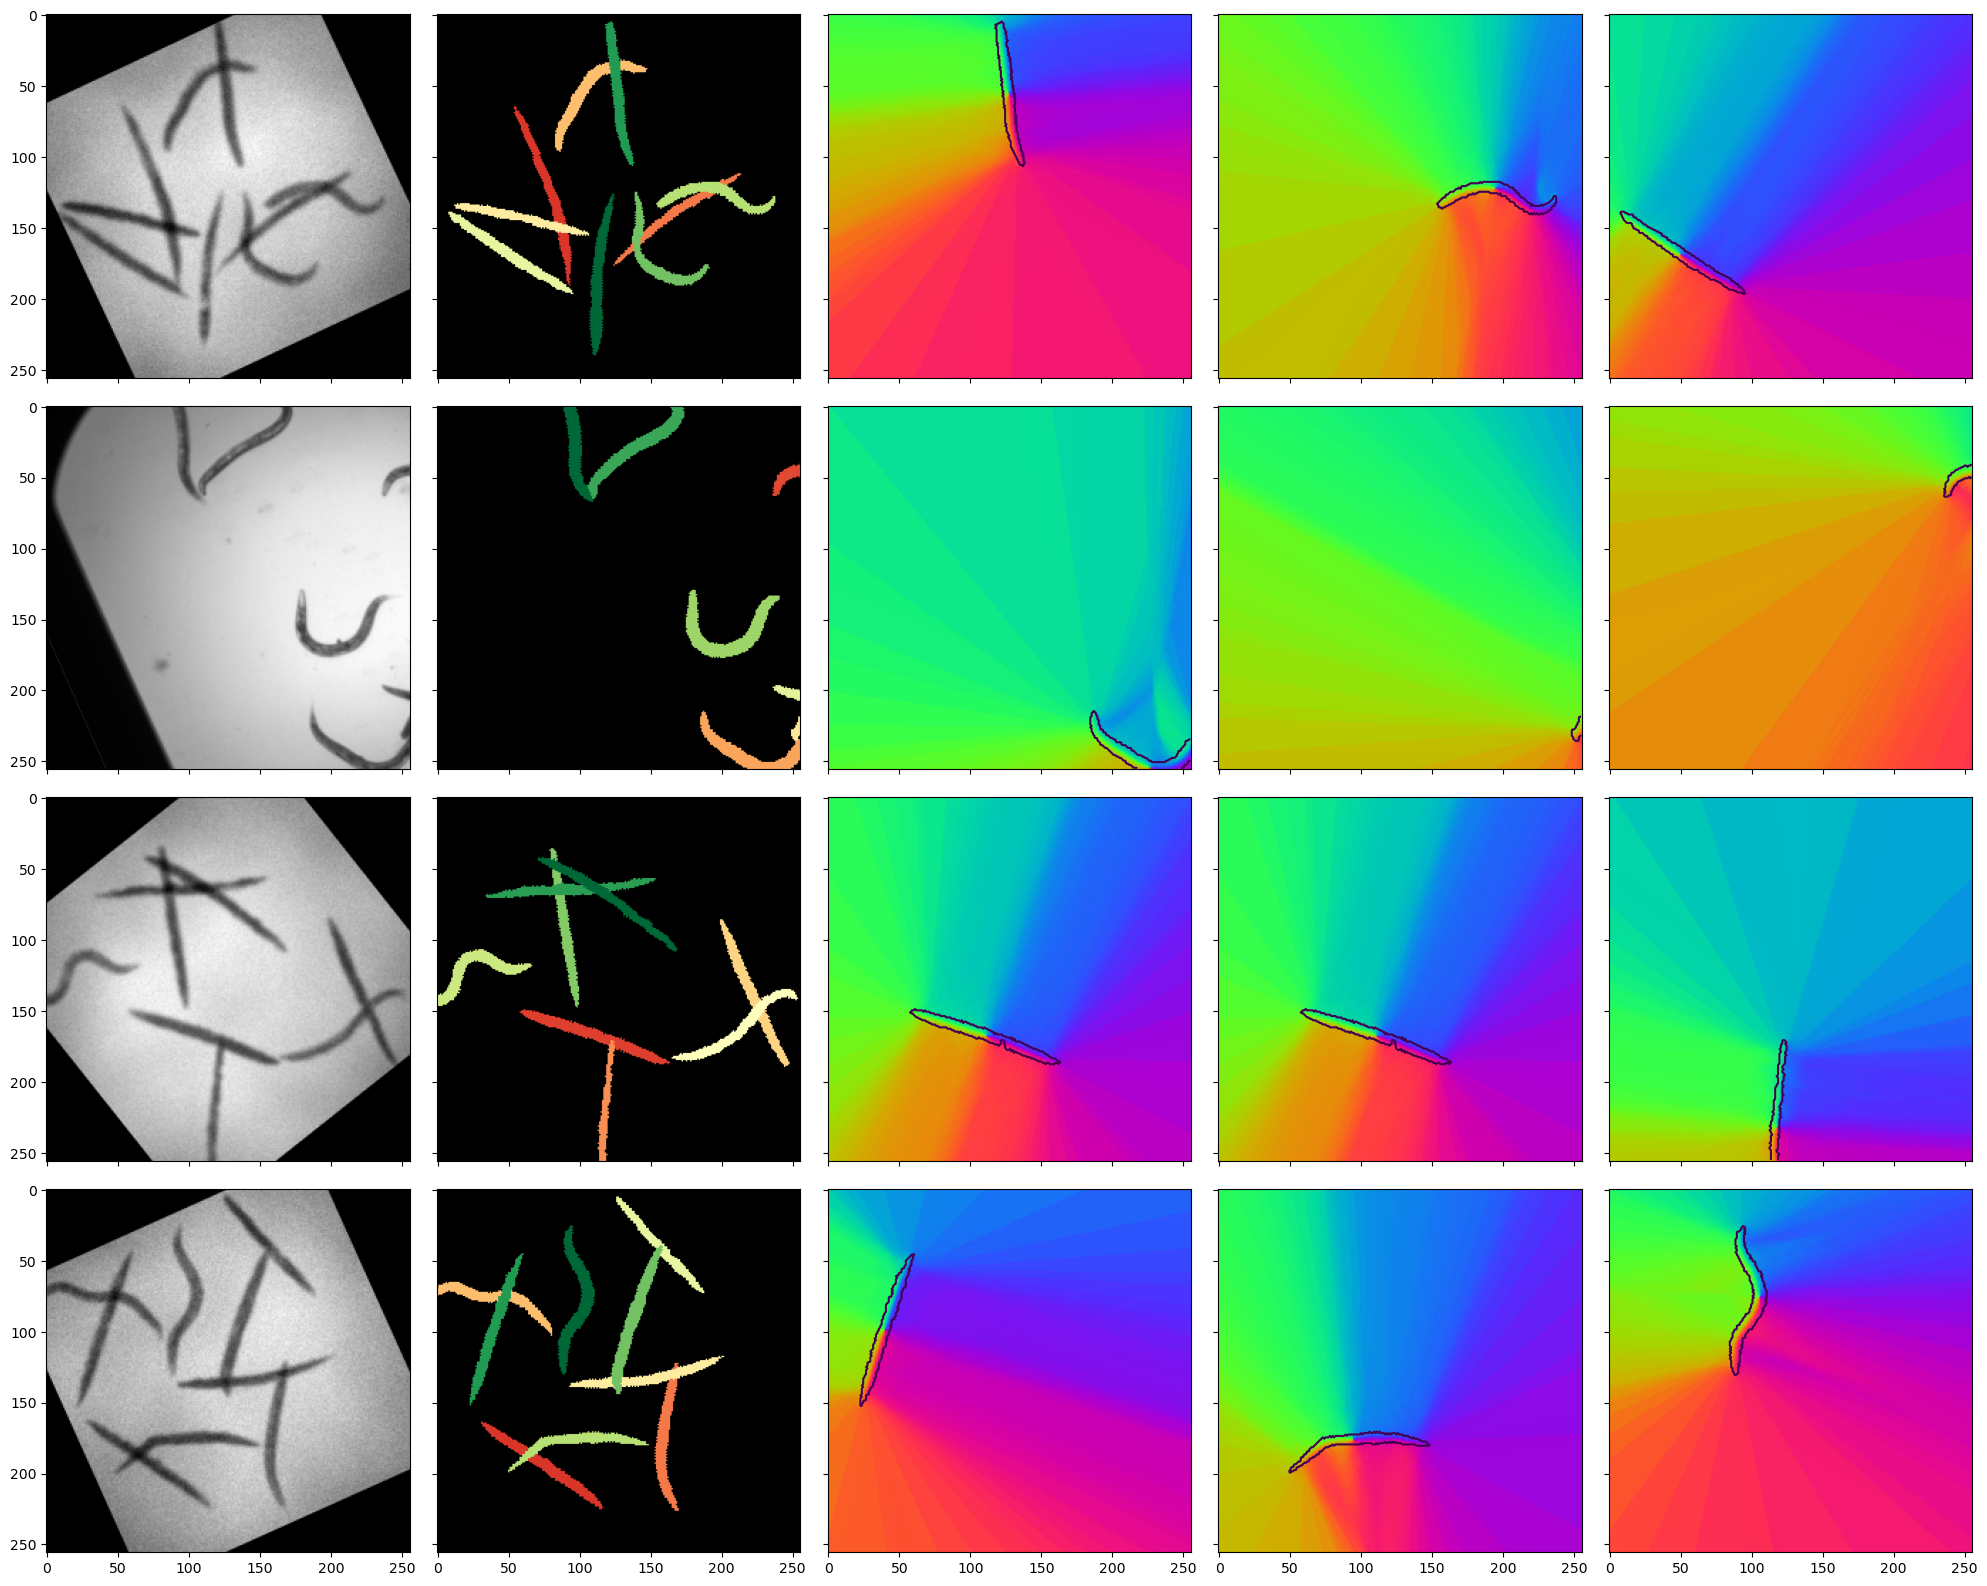

In [3]:
from pprint import pprint

from matplotlib import pyplot as plt
import numpy as np

from crossgoose.my_display import dp_to_rgb, get_custom_mask_cmap

DISP_T = ['patch_size','crop','flip_h','flip_v','affine']

batch =next(iter(train_data))
bs = len(batch['image'])
n,m = bs,5
rng = np.random.default_rng(0)
label_cmap = get_custom_mask_cmap()
fig,axs = plt.subplots(n,m,figsize=(m*4,n*4),sharex=True,sharey=True)
for i in range(bs):
    pprint({k:batch['transforms'][i].get(k,None) for k in DISP_T})
    # pprint(batch['transforms'][i])
    image = batch['image'][i,0].cpu().numpy()
    labels = batch['labels'][i].cpu().numpy()
    unique_l = list(set(np.unique(labels)) - set([0]))
    
    h,w = image.shape
    axs[i,0].imshow(image,cmap='gray')
    axs[i,1].imshow(labels,cmap=label_cmap)
    for k in range(3):
        l_pick = rng.choice(unique_l)
        m = labels==l_pick
        axs[i,2+k].contour(m)
        f = batch['flows'][i].query_flow_grid(l_pick,(h,w))
        axs[i,2+k].imshow(dp_to_rgb(f))

fig.tight_layout()